# Merge LoRA Adapters → Standalone Models

Folds each model family's LoRA adapter into its **bf16 base model** (`merge_and_unload`, like the prior study's `convertFastModels.ipynb`) and saves a full standalone model + tokenizer. Merged models load without PEFT and are what the app / faster inference paths consume.

| Item | Detail |
|---|---|
| **Dataset** | set `DATASET_KEY` in Cell 1 (`mentalchat16k` first; switch to `amod` later) |
| **Method** | base model loaded in bf16 **on CPU** (GPU untouched, no quantization loss in the merged weights) |
| **Output** | `../models/chat_models/<dataset>/<model>_merged/` (~3–6 GB each, ~15 GB for all three) |
| **Caching** | a finished merge is skipped on re-run; delete the `_merged` folder to redo |
| **Verify** | each merged model is loaded fresh in 4-bit on the GPU and generates a short reply |

In [1]:
# Cell 1 — Setup
import os
os.environ["PYTHONUTF8"] = "1"
os.environ["BNB_CUDA_VERSION"] = "130"  # for the 4-bit verification loads

import gc
import time

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

import ft_utils

DATASET_KEY = "mentalchat16k"   # amod | mentalchat16k

MODELS = list(ft_utils.CFG["models"])
print(f"Merging {MODELS} adapters trained on {DATASET_KEY}")

Merging ['gemma2', 'llama32', 'qwen3'] adapters trained on mentalchat16k


In [2]:
# Cell 2 — Merge each adapter into its bf16 base model (CPU)
def merge_one(model_key):
    mcfg = ft_utils.CFG["models"][model_key]
    adapter_dir = ft_utils.MODELS_ROOT / DATASET_KEY / model_key
    out_dir = ft_utils.MODELS_ROOT / DATASET_KEY / f"{model_key}_merged"
    if (out_dir / "config.json").exists():
        print(f"[cached]  {out_dir.name}")
        return
    if not (adapter_dir / "adapter_config.json").exists():
        print(f"[skipped] {model_key} — adapter not trained yet")
        return

    print(f"[merging] {model_key}: {mcfg['base_id']} + {adapter_dir.name} (bf16, CPU)")
    start = time.time()
    base = AutoModelForCausalLM.from_pretrained(
        mcfg["base_id"], dtype=torch.bfloat16, device_map="cpu")
    model = PeftModel.from_pretrained(base, str(adapter_dir))
    model = model.merge_and_unload()

    out_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(out_dir, safe_serialization=True)
    AutoTokenizer.from_pretrained(str(adapter_dir)).save_pretrained(out_dir)

    del model, base
    gc.collect()
    size = sum(f.stat().st_size for f in out_dir.rglob("*") if f.is_file()) / 1e9
    print(f"          saved {size:.1f} GB in {(time.time() - start) / 60:.1f} min -> {out_dir}")


for mk in MODELS:
    merge_one(mk)

[cached]  gemma2_merged
[cached]  llama32_merged
[cached]  qwen3_merged


In [3]:
# Cell 3 — Verify: load each merged model in 4-bit on the GPU and generate
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=torch.bfloat16,
                         bnb_4bit_use_double_quant=True)
TEST_PROMPT = "Lately I feel anxious all the time and I can't sleep well. What can I do?"

for mk in MODELS:
    out_dir = ft_utils.MODELS_ROOT / DATASET_KEY / f"{mk}_merged"
    if not (out_dir / "config.json").exists():
        print(f"[skipped] {mk}_merged not found")
        continue
    mcfg = ft_utils.CFG["models"][mk]
    kwargs = dict(quantization_config=bnb, device_map="auto", dtype=torch.bfloat16)
    if mcfg.get("attn_implementation"):
        kwargs["attn_implementation"] = mcfg["attn_implementation"]
    model = AutoModelForCausalLM.from_pretrained(str(out_dir), **kwargs)
    tokenizer = AutoTokenizer.from_pretrained(str(out_dir))
    model.eval()

    prompt = ft_utils.PROMPT_FORMATTERS[mk](TEST_PROMPT)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=60, do_sample=False,
                             pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id)
    reply = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(f"--- {mk}_merged ---")
    print(reply[:300].strip(), "\n")

    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()
print("All merged models verified.")

This can be used to load a bitsandbytes version built with a CUDA version that is different from the PyTorch CUDA version.
If this was unintended set the BNB_CUDA_VERSION variable to an empty string: export BNB_CUDA_VERSION=

W0720 20:19:12.463000 18732 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

c:\Users\laoli\OneDrive\Desktop\MultiAgent2\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
c:\Users\laoli\OneDrive\Desktop\MultiAgent2\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


--- gemma2_merged ---
It's understandable that you're feeling anxious and struggling with sleep. These symptoms can be distressing and impact your daily life. Here are some suggestions to help you manage your anxiety and improve your sleep:

1. Establish a bedtime routine: Create a consistent routine before bed to signal 



Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


--- llama32_merged ---
It sounds like you're experiencing a lot of anxiety and difficulty sleeping. It can be really challenging when these feelings are persistent and affect your overall well-being. Here are some suggestions that might help:

1. Practice relaxation techniques: Engaging in activities that promote relaxati 



Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

--- qwen3_merged ---
Feeling anxious all the time and having trouble sleeping can be really challenging. It's important to remember that you're not alone in experiencing these symptoms, and there are steps you can take to help manage them. Here are some suggestions:

1. Establish a bedtime routine: Creating a consistent 

All merged models verified.


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

gemma2   merged-bf16    13.9 tok/s | 7.20 s per 100-token reply
         VRAM free again: 7.2 GB


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

c:\Users\laoli\OneDrive\Desktop\MultiAgent2\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
c:\Users\laoli\OneDrive\Desktop\MultiAgent2\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


gemma2   merged-4bit    11.7 tok/s | 8.54 s per 100-token reply
         VRAM free again: 7.2 GB


...

qwen3    merged-bf16    19.6 tok/s | 5.11 s per 100-token reply
         VRAM free again: 7.2 GB


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

qwen3    merged-4bit    12.6 tok/s | 7.91 s per 100-token reply
         VRAM free again: 7.2 GB


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

qwen3    adapter-4bit    6.7 tok/s | 14.96 s per 100-token reply
         VRAM free again: 7.2 GB
Saved C:\Users\laoli\OneDrive\Desktop\MultiAgent2\fine_tuning_chatbot\results\merge_benchmark.csv


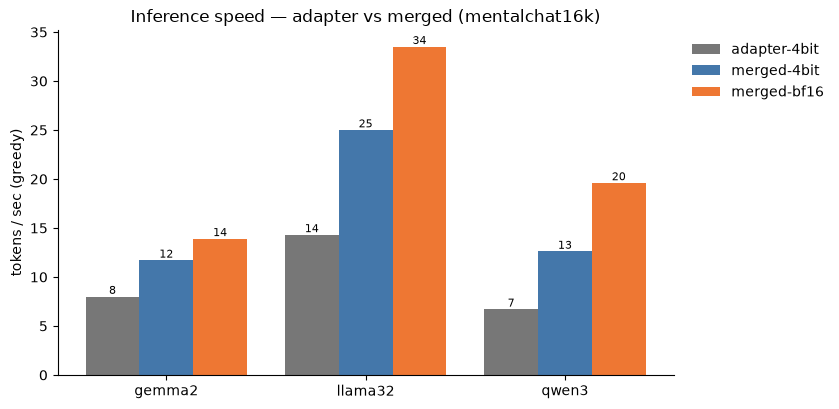

,model,variant,tokens_per_sec,latency_100tok_s
0,gemma2,merged-bf16,13.9,7.20
1,gemma2,merged-4bit,11.7,8.54
2,gemma2,adapter-4bit,8.0,12.53
3,llama32,merged-bf16,33.5,2.99
4,llama32,merged-4bit,25.0,4.00
5,llama32,adapter-4bit,14.3,6.98
6,qwen3,merged-bf16,19.6,5.11
7,qwen3,merged-4bit,12.6,7.91
8,qwen3,adapter-4bit,6.7,14.96


In [4]:
# Cell 4 — Performance benchmark: adapter vs merged (tokens/sec)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BENCH_PROMPTS = [
    "Lately I feel anxious all the time and I can't sleep well. What can I do?",
    "I keep procrastinating on my studies and then hate myself for it.",
    "My parents argue constantly and it makes me want to avoid going home.",
]
N_NEW = 100

bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=torch.bfloat16,
                         bnb_4bit_use_double_quant=True)


def load_variant(mk, variant):
    mcfg = ft_utils.CFG["models"][mk]
    kwargs = dict(device_map="auto", dtype=torch.bfloat16)
    if mcfg.get("attn_implementation"):
        kwargs["attn_implementation"] = mcfg["attn_implementation"]
    merged_dir = str(ft_utils.MODELS_ROOT / DATASET_KEY / f"{mk}_merged")
    adapter_dir = str(ft_utils.MODELS_ROOT / DATASET_KEY / mk)
    if variant == "adapter-4bit":     # the evaluation notebooks' inference path
        model = AutoModelForCausalLM.from_pretrained(mcfg["base_id"], quantization_config=bnb, **kwargs)
        model = PeftModel.from_pretrained(model, adapter_dir)
        tok = AutoTokenizer.from_pretrained(adapter_dir)
    elif variant == "merged-4bit":    # merged weights, same memory footprint
        model = AutoModelForCausalLM.from_pretrained(merged_dir, quantization_config=bnb, **kwargs)
        tok = AutoTokenizer.from_pretrained(merged_dir)
    else:                             # merged-bf16: full precision, most VRAM
        model = AutoModelForCausalLM.from_pretrained(merged_dir, **kwargs)
        tok = AutoTokenizer.from_pretrained(merged_dir)
    model.eval()
    model.config.use_cache = True
    return model, tok


def bench(model, tok, mk):
    prompt_fn = ft_utils.PROMPT_FORMATTERS[mk]
    pad = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id
    ids = tok(prompt_fn(BENCH_PROMPTS[0]), return_tensors="pt").to(model.device)
    with torch.no_grad():                                   # warmup
        model.generate(**ids, max_new_tokens=8, do_sample=False, pad_token_id=pad)
    total_tok, times = 0, []
    for p in BENCH_PROMPTS:
        ids = tok(prompt_fn(p), return_tensors="pt").to(model.device)
        torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad():                               # forced full length for fair timing
            out = model.generate(**ids, max_new_tokens=N_NEW, min_new_tokens=N_NEW,
                                 do_sample=False, pad_token_id=pad)
        torch.cuda.synchronize()
        times.append(time.time() - t0)
        total_tok += out.shape[1] - ids["input_ids"].shape[1]
    return total_tok / sum(times), sum(times) / len(times)


rows = []
for mk in MODELS:
    if not (ft_utils.MODELS_ROOT / DATASET_KEY / f"{mk}_merged" / "config.json").exists():
        print(f"[skipped] {mk} — no merged model")
        continue
    # largest footprint first — VRAM fragmentation from earlier loads can
    # silently spill a late big load into system RAM and distort its numbers
    for variant in ("merged-bf16", "merged-4bit", "adapter-4bit"):
        try:
            model, tok = load_variant(mk, variant)
        except torch.OutOfMemoryError:
            print(f"{mk:8s} {variant:12s} OOM — skipped")
            torch.cuda.empty_cache()
            continue
        tps, latency = bench(model, tok, mk)
        rows.append({"model": mk, "variant": variant,
                     "tokens_per_sec": round(tps, 1), "latency_100tok_s": round(latency, 2)})
        print(f"{mk:8s} {variant:12s} {tps:6.1f} tok/s | {latency:.2f} s per {N_NEW}-token reply")
        del model, tok
        gc.collect()
        torch.cuda.empty_cache()
        print(f"         VRAM free again: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

perf = pd.DataFrame(rows)
perf.to_csv(ft_utils.RESULTS_ROOT / "merge_benchmark.csv", index=False)
print("Saved", ft_utils.RESULTS_ROOT / "merge_benchmark.csv")

V_COLORS = {"adapter-4bit": "#777777", "merged-4bit": "#4477AA", "merged-bf16": "#EE7733"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})
models_present = [m for m in MODELS if not perf[perf["model"] == m].empty]
x = np.arange(len(models_present))
width = 0.27
plt.figure(figsize=(8.5, 4.2))
for k, variant in enumerate(V_COLORS):
    vals = [perf[(perf["model"] == m) & (perf["variant"] == variant)]["tokens_per_sec"].max()
            for m in models_present]
    vals = [0 if pd.isna(v) else v for v in vals]
    bars = plt.bar(x + (k - 1) * width, vals, width, color=V_COLORS[variant], label=variant)
    plt.bar_label(bars, fmt="{:.0f}", fontsize=8)
plt.xticks(x, models_present)
plt.ylabel("tokens / sec (greedy)")
plt.title(f"Inference speed — adapter vs merged ({DATASET_KEY})")
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig(ft_utils.RESULTS_ROOT / "chart_merge_speed.png", dpi=150, bbox_inches="tight")
plt.show()
perf

## Notes

- Merged models are standalone: `AutoModelForCausalLM.from_pretrained("models/chat_models/<dataset>/<model>_merged")` — no PEFT needed, load in bf16 or 4-bit as required.
- Merging happens in full bf16 precision (not from the 4-bit training view), so the merged weights are exact `base + LoRA` — the 4-bit verification load only quantizes at inference time, same as training did.
- The benchmark (Cell 4) writes `results/merge_benchmark.csv` + `results/chart_merge_speed.png` — compare `adapter-4bit` (evaluation path) vs `merged-4bit` (no PEFT overhead) vs `merged-bf16` (full precision, most VRAM).
- To merge the amod adapters later: change `DATASET_KEY` in Cell 1 and Run All.
- The adapter folders stay untouched — the merged copies are additive (~15 GB for all three; `models/` is gitignored).